In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print("All libraries loaded!")

All libraries loaded!


In [2]:
import urllib.request

urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/gagolews/teaching-data/master/marek/nhanes_adult_male_bmx_2020.csv",
    "nhanes_adult_male_bmx_2020.csv"
)

urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/gagolews/teaching-data/master/marek/nhanes_adult_female_bmx_2020.csv",
    "nhanes_adult_female_bmx_2020.csv"
)

print("Files downloaded!")

Files downloaded!


In [3]:
male = np.genfromtxt("nhanes_adult_male_bmx_2020.csv", delimiter=",", skip_header=1)
female = np.genfromtxt("nhanes_adult_female_bmx_2020.csv", delimiter=",", skip_header=1)

male = male[~np.isnan(male).any(axis=1)]
female = female[~np.isnan(female).any(axis=1)]

print("Male shape:", male.shape)
print("Female shape:", female.shape)
print("Male first row:", male[0])
print("Female first row:", female[0])

Male shape: (4081, 7)
Female shape: (4221, 7)
Male first row: [ 98.8 182.3  42.   40.1  38.2 108.2 120.4]
Female first row: [ 97.1 160.2  34.7  40.8  35.8 126.1 117.9]


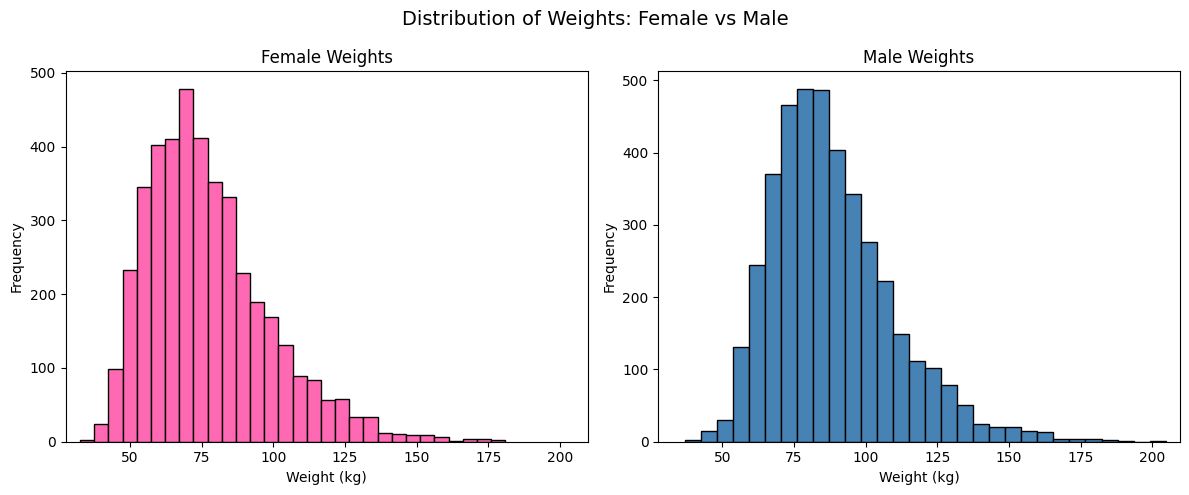

In [ ]:
male_weights = male[:, 0]
female_weights = female[:, 0]

x_min = min(male_weights.min(), female_weights.min()) - 5
x_max = max(male_weights.max(), female_weights.max()) + 5

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(female_weights, bins=30, color='hotpink', edgecolor='black')
plt.xlim(x_min, x_max)
plt.title("Female Weights")
plt.xlabel("Weight (kg)")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(male_weights, bins=30, color='steelblue', edgecolor='black')
plt.xlim(x_min, x_max)
plt.title("Male Weights")
plt.xlabel("Weight (kg)")
plt.ylabel("Frequency")

plt.suptitle("Distribution of Weights: Female vs Male", fontsize=14)
plt.tight_layout()
plt.show()

/tmp/ipykernel_54828/3837291177.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([female_weights, male_weights],


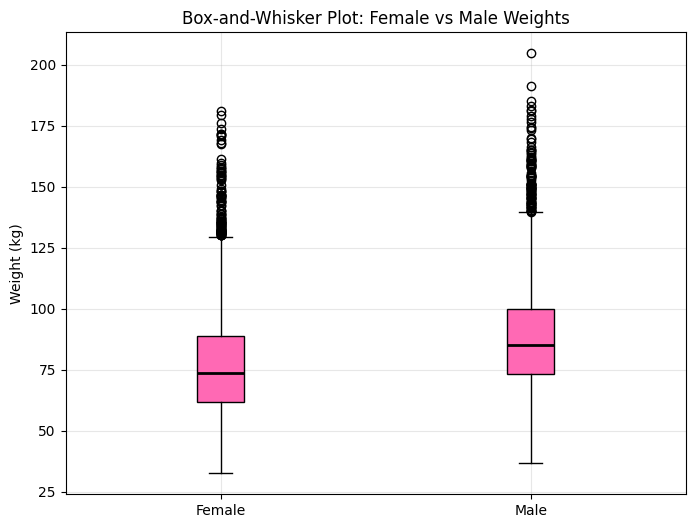

In [5]:
plt.figure(figsize=(8, 6))

plt.boxplot([female_weights, male_weights],
            labels=['Female', 'Male'],
            patch_artist=True,
            boxprops=dict(facecolor='hotpink'),
            medianprops=dict(color='black', linewidth=2))

plt.title("Box-and-Whisker Plot: Female vs Male Weights")
plt.ylabel("Weight (kg)")
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
print("=" * 45)
print("        FEMALE WEIGHT STATISTICS")
print("=" * 45)
print(f"Mean        : {np.mean(female_weights):.2f} kg")
print(f"Median      : {np.median(female_weights):.2f} kg")
print(f"Std Dev     : {np.std(female_weights):.2f} kg")
print(f"Variance    : {np.var(female_weights):.2f}")
print(f"Min         : {np.min(female_weights):.2f} kg")
print(f"Max         : {np.max(female_weights):.2f} kg")
print(f"Skewness    : {stats.skew(female_weights):.4f}")
print(f"Kurtosis    : {stats.kurtosis(female_weights):.4f}")

print("\n" + "=" * 45)
print("         MALE WEIGHT STATISTICS")
print("=" * 45)
print(f"Mean        : {np.mean(male_weights):.2f} kg")
print(f"Median      : {np.median(male_weights):.2f} kg")
print(f"Std Dev     : {np.std(male_weights):.2f} kg")
print(f"Variance    : {np.var(male_weights):.2f}")
print(f"Min         : {np.min(male_weights):.2f} kg")
print(f"Max         : {np.max(male_weights):.2f} kg")
print(f"Skewness    : {stats.skew(male_weights):.4f}")
print(f"Kurtosis    : {stats.kurtosis(male_weights):.4f}")

        FEMALE WEIGHT STATISTICS
Mean        : 77.40 kg
Median      : 73.60 kg
Std Dev     : 21.54 kg
Variance    : 464.08
Min         : 32.60 kg
Max         : 180.90 kg
Skewness    : 1.0334
Kurtosis    : 1.4010

         MALE WEIGHT STATISTICS
Mean        : 88.36 kg
Median      : 85.00 kg
Std Dev     : 21.42 kg
Variance    : 458.77
Min         : 36.80 kg
Max         : 204.60 kg
Skewness    : 0.9843
Kurtosis    : 1.4743


In [7]:
import pandas as pd

female_bmi = female[:, 0] / ((female[:, 1] / 100) ** 2)

zfemale = (female - female.mean(axis=0)) / female.std(axis=0)

print("zfemale shape:", zfemale.shape)
print("Mean of each column:", zfemale.mean(axis=0).round(4))
print("Std of each column :", zfemale.std(axis=0).round(4))

zfemale shape: (4221, 7)
Mean of each column: [ 0.  0. -0. -0.  0. -0.  0.]
Std of each column : [1. 1. 1. 1. 1. 1. 1.]


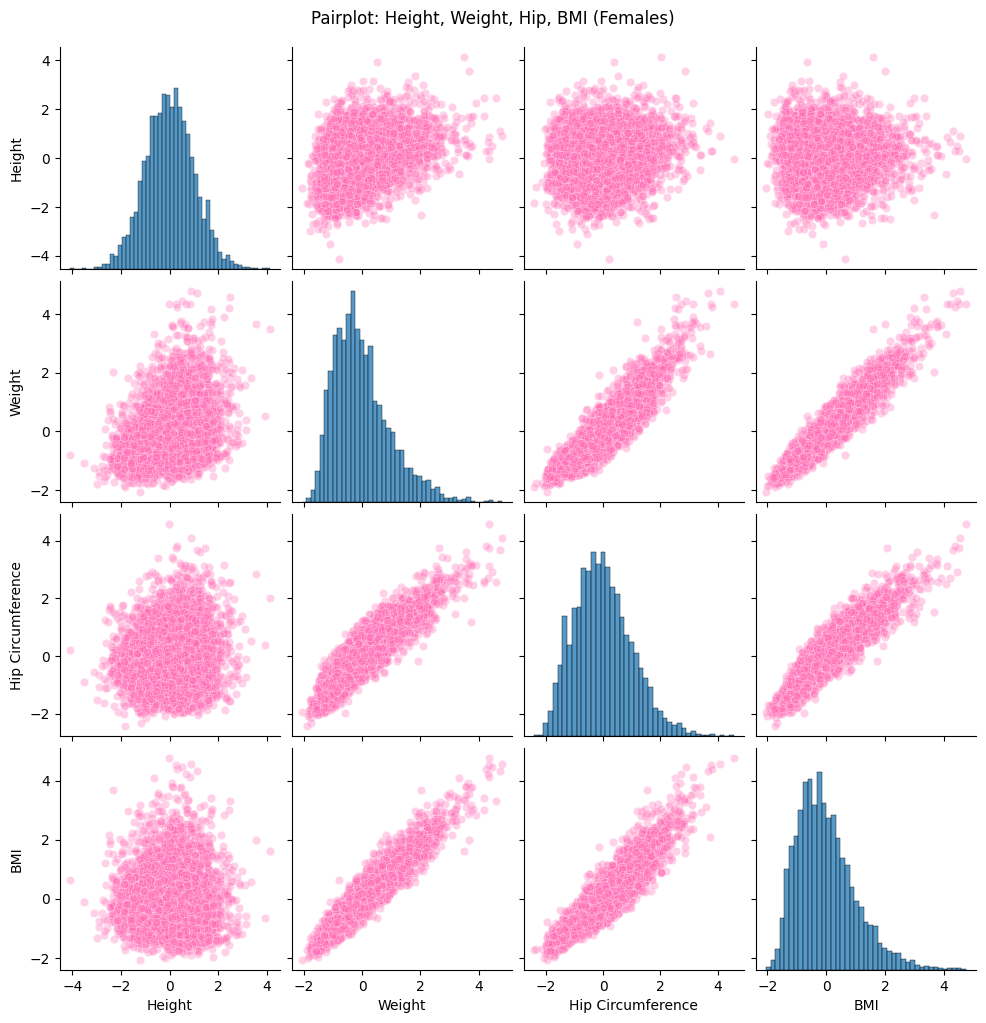

In [8]:
zheight = zfemale[:, 1]
zweight = zfemale[:, 0]
zhip    = zfemale[:, 6]
zbmi    = (female_bmi - female_bmi.mean()) / female_bmi.std()

df = pd.DataFrame({
    'Height': zheight,
    'Weight': zweight,
    'Hip Circumference': zhip,
    'BMI': zbmi
})

sns.pairplot(df, plot_kws={'alpha': 0.3, 'color': 'hotpink'})
plt.suptitle("Pairplot: Height, Weight, Hip, BMI (Females)", y=1.02)
plt.show()

In [9]:
cols = {'Height': zheight, 'Weight': zweight, 'Hip': zhip, 'BMI': zbmi}
col_names = list(cols.keys())
col_vals  = list(cols.values())

print("PEARSON CORRELATION:")
print(f"{'':12}", end="")
for n in col_names:
    print(f"{n:12}", end="")
print()
for i, n1 in enumerate(col_names):
    print(f"{n1:12}", end="")
    for j, n2 in enumerate(col_names):
        r, _ = stats.pearsonr(col_vals[i], col_vals[j])
        print(f"{r:12.4f}", end="")
    print()

print("\nSPEARMAN CORRELATION:")
print(f"{'':12}", end="")
for n in col_names:
    print(f"{n:12}", end="")
print()
for i, n1 in enumerate(col_names):
    print(f"{n1:12}", end="")
    for j, n2 in enumerate(col_names):
        r, _ = stats.spearmanr(col_vals[i], col_vals[j])
        print(f"{r:12.4f}", end="")
    print()

PEARSON CORRELATION:
            Height      Weight      Hip         BMI         
Height            1.0000      0.3455      0.1265      0.0331
Weight            0.3455      1.0000      0.9046      0.9459
Hip               0.1265      0.9046      1.0000      0.9212
BMI               0.0331      0.9459      0.9212      1.0000

SPEARMAN CORRELATION:
            Height      Weight      Hip         BMI         
Height            1.0000      0.3389      0.1086      0.0199
Weight            0.3389      1.0000      0.9002      0.9380
Hip               0.1086      0.9002      1.0000      0.9231
BMI               0.0199      0.9380      0.9231      1.0000


In [10]:
female_whr  = female[:, 5] / female[:, 1]
female_whip = female[:, 5] / female[:, 6]

male_whr  = male[:, 5] / male[:, 1]
male_whip = male[:, 5] / male[:, 6]

female = np.column_stack([female, female_whr, female_whip])
male = np.column_stack([male, male_whr, male_whip])

print("Female shape:", female.shape)
print("Male shape:", male.shape)

Female shape: (4221, 9)
Male shape: (4081, 9)


/tmp/ipykernel_54828/1230636371.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


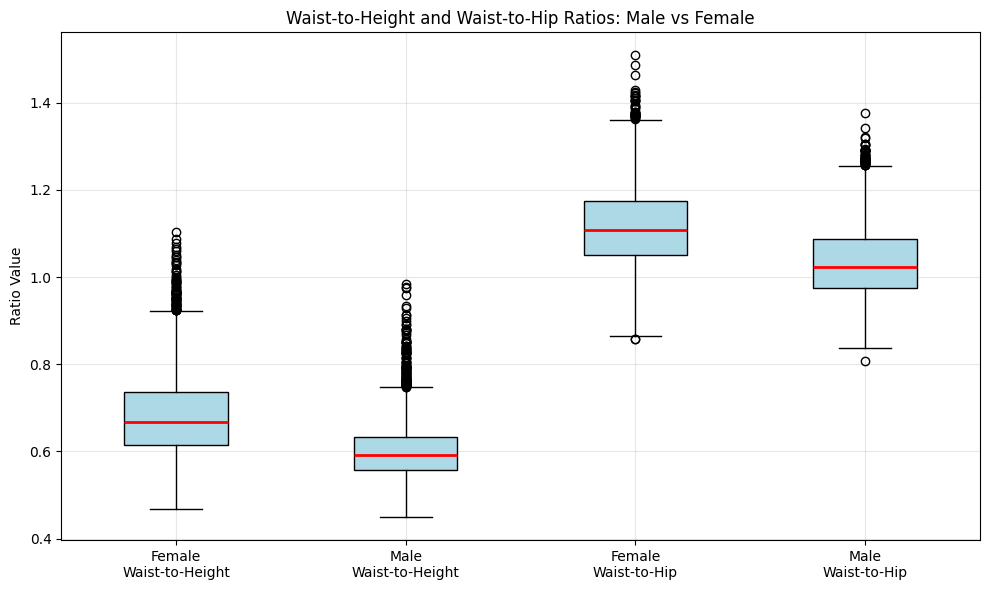

In [11]:
plt.figure(figsize=(10, 6))

plt.boxplot(
    [female[:, 7], male[:, 7], female[:, 8], male[:, 8]],
    labels=['Female\nWaist-to-Height', 'Male\nWaist-to-Height',
            'Female\nWaist-to-Hip', 'Male\nWaist-to-Hip'],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue'),
    medianprops=dict(color='red', linewidth=2)
)

plt.title("Waist-to-Height and Waist-to-Hip Ratios: Male vs Female")
plt.ylabel("Ratio Value")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
female_bmi = female[:, 0] / ((female[:, 1] / 100) ** 2)

sorted_indices = np.argsort(female_bmi)

lowest_indices  = sorted_indices[:5]
highest_indices = sorted_indices[-5:]

col_names = ["Weight", "Height", "ArmLen",
             "LegLen", "ArmCirc", "Waist",
             "Hip", "WHtR", "WHipR"]

print("=" * 75)
print("5 FEMALES WITH LOWEST BMI")
print("=" * 75)
for i, idx in enumerate(lowest_indices):
    print(f"Person {i+1}: {female[idx]} BMI={female_bmi[idx]:.2f}")

print("\n" + "=" * 75)
print("5 FEMALES WITH HIGHEST BMI")
print("=" * 75)
for i, idx in enumerate(highest_indices):
    print(f"Person {i+1}: {female[idx]} BMI={female_bmi[idx]:.2f}")

5 FEMALES WITH LOWEST BMI
Person 1: [ 32.6        151.5         32.4         33.4         20.4
  77.3         64.7          0.51023102   1.19474498] BMI=14.20
Person 2: [ 36.9        158.8         32.          38.4         19.
  80.2         62.7          0.50503778   1.27910686] BMI=14.63
Person 3: [ 44.3        172.9         37.5         39.          20.
  83.          68.8          0.48004627   1.20639535] BMI=14.82
Person 4: [ 37.7        158.3         35.5         38.8         19.8
  74.          66.2          0.46746684   1.11782477] BMI=15.04
Person 5: [ 42.7        166.4         35.8         38.7         20.3
  80.6         68.7          0.484375     1.17321689] BMI=15.42

5 FEMALES WITH HIGHEST BMI
Person 1: [168.9        162.2         40.4         34.          46.
 173.3        164.9          1.06843403   1.05093996] BMI=64.20
Person 2: [173.4        163.7         40.          33.5         51.5
 171.4        149.           1.04703726   1.15033557] BMI=64.71
Person 3: [171.1  

In [ ]:
from google.colab import drive
drive.mount('/content/drive')